# Test H5 calibration workflow

## Example notebook

This notebook shows how to calibrate an HDF5 FLIM dataset channel-by-channel,
save the results into `*_calib.h5`, and inspect the flattened `calibration`
datasets written with channel as the last dimension.


In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from brighteyes_flim import H5DataCalibrator, calibrate_h5_file


## Run calibration from a fluorescence reference

- `reference_type="ref"` means the reference histogram is used to estimate an IRF.
- `tau_ref=None` means the reference lifetime is estimated automatically.
- `fit_mode="model_shift"` is used here as the default workflow.


In [2]:
DATA_KEY = "data"
REFERENCE_KEY = "data"
TAU_REF = 2.5

f_ref = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
f_data = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"

output_path = calibrate_h5_file(
    f_data,
    f_ref,
    data_key=DATA_KEY,
    reference_key=REFERENCE_KEY,
    reference_type="ref",
    tau_ref=TAU_REF,
    fit_mode="model_shift",
    fit_type="circular",
    C_ref=1.0,
    irf_iterations=300,
    regularization=0,
    overwrite=True,
)

print(output_path)


Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.7252747

## Inspect flattened calibration summary


In [3]:
with h5py.File(output_path, "r") as hf:
    calibration = hf["calibration"]
    summary_df = pd.DataFrame(
        {
            "channel": calibration["channel_index"][()],
            "reference_channel": calibration["reference_channel_index"][()],
            "C": calibration["C"][()],
            "tau_ns": calibration["tau_ns"][()],
            "tau_ref_ns": calibration["tau_ref_ns"][()],
            "delta_t_bins": calibration["delta_t_correction_bins"][()],
            "delta_t_ns": calibration["delta_t_correction_ns"][()],
            "irf_source": calibration["irf_source"].asstr()[()],
        }
    )

display(summary_df.round(6))


,channel,reference_channel,C,tau_ns,tau_ref_ns,delta_t_bins,delta_t_ns,irf_source
0,0,0,0.050867,1.465084,2.5,-5.053218,-1.388247,estimated_from_ref
1,1,1,0.533665,1.514509,2.5,-5.000000,-1.373626,estimated_from_ref
2,2,2,0.956897,1.432491,2.5,-5.000000,-1.373626,estimated_from_ref
3,3,3,0.836594,1.549800,2.5,-5.027940,-1.381302,estimated_from_ref
4,4,4,1.351321,1.535075,2.5,-5.000000,-1.373626,estimated_from_ref
5,5,5,0.250842,1.515642,2.5,-5.017987,-1.378568,estimated_from_ref
6,6,6,9.466520,1.490570,2.5,-5.045218,-1.386049,estimated_from_ref
7,7,7,9.466849,1.501029,2.5,-5.000000,-1.373626,estimated_from_ref
8,8,8,1.473612,1.458697,2.5,-5.000000,-1.373626,estimated_from_ref
9,9,9,0.005196,1.566439,2.5,-5.040870,-1.384854,estimated_from_ref


/tmp/ipykernel_2402609/19800689.py:39: RuntimeWarning: invalid value encountered in divide
  gaussian_tau_ref = np.exp(-0.5 * ((y_tau_ref - mean_tau_ref) / std_tau_ref) ** 2) / (std_tau_ref * np.sqrt(2 * np.pi))
/tmp/ipykernel_2402609/19800689.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


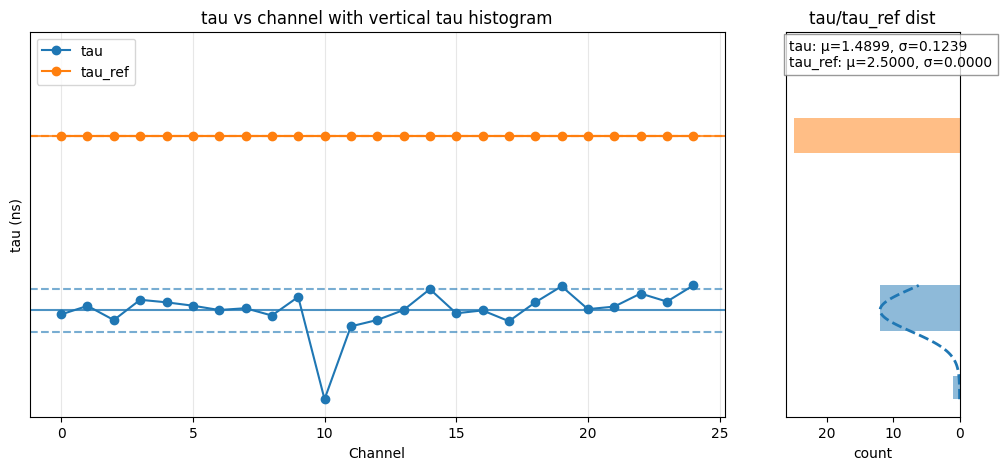

/tmp/ipykernel_2402609/19800689.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


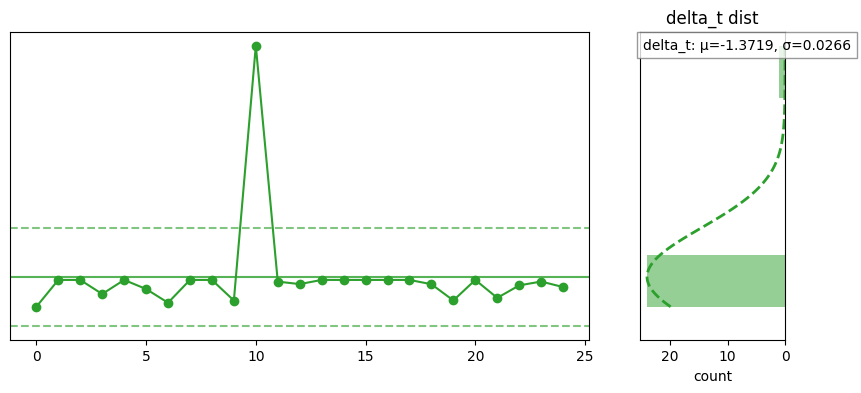

In [4]:
channels = summary_df["channel"]
tau = summary_df["tau_ns"]
tau_ref = summary_df["tau_ref_ns"]
delta = summary_df["delta_t_ns"]

mean_tau = tau.mean()
std_tau = tau.std()
mean_tau_ref = tau_ref.mean()
std_tau_ref = tau_ref.std()
mean_delta = delta.mean()
std_delta = delta.std()

fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.14)
ax = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax)

ax.plot(channels, tau, "o-", label="tau", color="tab:blue")
ax.plot(channels, tau_ref, "o-", label="tau_ref", color="tab:orange")
ax.axhline(mean_tau, color="tab:blue", linestyle="-", alpha=0.8)
ax.axhline(mean_tau + std_tau, color="tab:blue", linestyle="--", alpha=0.6)
ax.axhline(mean_tau - std_tau, color="tab:blue", linestyle="--", alpha=0.6)
ax.axhline(mean_tau_ref, color="tab:orange", linestyle="-", alpha=0.8)
ax.axhline(mean_tau_ref + std_tau_ref, color="tab:orange", linestyle="--", alpha=0.6)
ax.axhline(mean_tau_ref - std_tau_ref, color="tab:orange", linestyle="--", alpha=0.6)

ax_hist.hist(tau, bins=5, orientation="horizontal", color="tab:blue", alpha=0.5, label="tau")
ax_hist.hist(tau_ref, bins=5, orientation="horizontal", color="tab:orange", alpha=0.5, label="tau_ref")

# Gaussian for tau
y_tau = np.linspace(tau.min(), tau.max(), 100)
gaussian_tau = np.exp(-0.5 * ((y_tau - mean_tau) / std_tau) ** 2) / (std_tau * np.sqrt(2 * np.pi))
max_count_tau = np.histogram(tau, bins=5)[0].max()
gaussian_tau_norm = gaussian_tau * max_count_tau / gaussian_tau.max()
ax_hist.plot(gaussian_tau_norm, y_tau, color="tab:blue", linestyle="--", linewidth=2, label="tau gaussian")

# Gaussian for tau_ref
y_tau_ref = np.linspace(tau_ref.min(), tau_ref.max(), 100)
gaussian_tau_ref = np.exp(-0.5 * ((y_tau_ref - mean_tau_ref) / std_tau_ref) ** 2) / (std_tau_ref * np.sqrt(2 * np.pi))
max_count_tau_ref = np.histogram(tau_ref, bins=5)[0].max()
gaussian_tau_ref_norm = gaussian_tau_ref * max_count_tau_ref / gaussian_tau_ref.max()
ax_hist.plot(gaussian_tau_ref_norm, y_tau_ref, color="tab:orange", linestyle="--", linewidth=2, label="tau_ref gaussian")

ax_hist.invert_xaxis()
ax_hist.set_yticks([])
ax_hist.set_xlabel("count")
ax_hist.set_title("tau/tau_ref dist")

ax_hist.text(
    0.02,
    0.98,
    f"tau: μ={mean_tau:.4f}, σ={std_tau:.4f}\ntau_ref: μ={mean_tau_ref:.4f}, σ={std_tau_ref:.4f}",
    transform=ax_hist.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
)

ax.set_xlabel("Channel")
ax.set_ylabel("tau (ns)")
ax.set_title("tau vs channel with vertical tau histogram")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(10, 4))
gs2 = fig2.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.14)
ax_delta = fig2.add_subplot(gs2[0])
ax_delta_hist = fig2.add_subplot(gs2[1], sharey=ax_delta)

ax_delta.plot(channels, delta, "o-", label="delta_t", color="tab:green")
ax_delta.axhline(mean_delta, color="tab:green", linestyle="-", alpha=0.8)
ax_delta.axhline(mean_delta + std_delta, color="tab:green", linestyle="--", alpha=0.6)
ax_delta.axhline(mean_delta - std_delta, color="tab:green", linestyle="--", alpha=0.6)

ax_delta_hist.hist(delta, bins=5, orientation="horizontal", color="tab:green", alpha=0.5)

# Gaussian for delta_t
y_delta = np.linspace(delta.min(), delta.max(), 100)
gaussian_delta = np.exp(-0.5 * ((y_delta - mean_delta) / std_delta) ** 2) / (std_delta * np.sqrt(2 * np.pi))
max_count_delta = np.histogram(delta, bins=5)[0].max()
gaussian_delta_norm = gaussian_delta * max_count_delta / gaussian_delta.max()
ax_delta_hist.plot(gaussian_delta_norm, y_delta, color="tab:green", linestyle="--", linewidth=2, label="delta_t gaussian")

ax_delta_hist.invert_xaxis()
ax_delta_hist.set_yticks([])
ax_delta_hist.set_xlabel("count")
ax_delta_hist.set_title("delta_t dist")

ax_delta_hist.text(
    0.02,
    0.98,
    f"delta_t: μ={mean_delta:.4f}, σ={std_delta:.4f}",
    transform=ax_delta_hist.transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
)

fig2.tight_layout()
plt.show()

## Plot one calibrated channel from the flattened `(t, ch)` datasets


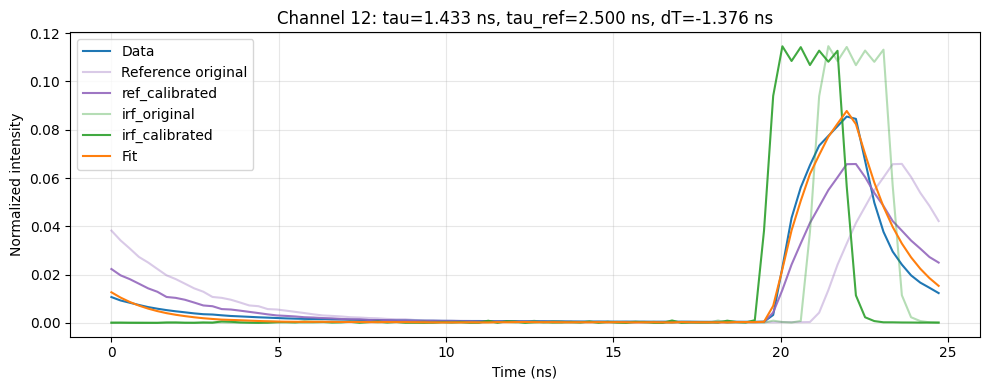

In [5]:
CHANNEL=12

with h5py.File(output_path, "r") as hf:
    calibration = hf["calibration"]
    calibrated_channels = calibration["channel_index"][()]
    column = int(np.where(calibrated_channels == CHANNEL)[0][0])

    data_hist = calibration["data_histogram_normalized"][:, column]
    ref_original = calibration["ref_original"][:, column]
    ref_calibrated = calibration["ref_calibrated"][:, column]
    irf_original = calibration["irf_original"][:, column]
    irf_calibrated = calibration["irf_calibrated"][:, column]
    fit_hist = calibration["fit"][:, column]
    period_ns = float(calibration.attrs["period_ns"])
    tau_ns = float(calibration["tau_ns"][column])
    tau_ref_ns = float(calibration["tau_ref_ns"][column])
    delta_t_ns = float(calibration["delta_t_correction_ns"][column])

t_ns = np.arange(data_hist.size, dtype=float) * period_ns / data_hist.size
ref_original_norm = ref_original / ref_original.sum()

plt.figure(figsize=(10, 4))
plt.plot(t_ns, data_hist, label="Data", color="tab:blue")
plt.plot(t_ns, ref_original_norm, label="Reference original", color="tab:purple", alpha=0.35)
plt.plot(t_ns, ref_calibrated, label="ref_calibrated", color="tab:purple", alpha=0.9)
plt.plot(t_ns, irf_original, label="irf_original", color="tab:green", alpha=0.35)
plt.plot(t_ns, irf_calibrated, label="irf_calibrated", color="tab:green", alpha=0.9)
plt.plot(t_ns, fit_hist, label="Fit", color="tab:orange")
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(
    f"Channel {CHANNEL}: tau={tau_ns:.3f} ns, tau_ref={tau_ref_ns:.3f} ns, dT={delta_t_ns:.3f} ns"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Direct IRF workflow

If the second file is already an IRF measurement, switch to `reference_type="irf"`.


In [6]:
# Example:
# f_irf = "/path/to/direct_irf_measurement.h5"
# output_path_irf = calibrate_h5_file(
#     f_data,
#     f_irf,
#     data_key="data",
#     reference_key="data",
#     reference_type="irf",
#     fit_mode="model_shift",
#     overwrite=True,
# )
# print(output_path_irf)


In [7]:
with h5py.File(output_path, "r") as hf:
    calibration = hf["calibration"]
    print("calibration keys:", list(calibration.keys()))
    print("data_histogram shape:", calibration["data_histogram"].shape)
    print("irf_calibrated shape:", calibration["irf_calibrated"].shape)
    print("covariance shape:", calibration["covariance"].shape)
    print("channel_index:", calibration["channel_index"][()])
    

calibration keys: ['C', 'channel_index', 'covariance', 'data_histogram', 'data_histogram_normalized', 'delta_t_correction_bins', 'delta_t_correction_ns', 'fit', 'input_data_metadata', 'input_reference_metadata', 'irf_calibrated', 'irf_original', 'irf_source', 'ref_calibrated', 'ref_original', 'reference_channel_index', 'tau_ns', 'tau_ref_ns']
data_histogram shape: (91, 25)
irf_calibrated shape: (91, 25)
covariance shape: (3, 3, 25)
channel_index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]


In [12]:
with h5py.File(output_path, "r") as hf:
    print(hf["calibration"].keys())
    print(hf["calibration"]["data_histogram"].shape)
    print(hf["calibration"]["irf_calibrated"].shape)
    print(hf["calibration"]["covariance"].shape)
    print(hf["calibration"]["channel_index"][()])
    print(hf["calibration"]["tau_ns"][:])
    print(hf["calibration"]["tau_ref_ns"][:])
    print(hf["calibration"]["delta_t_correction_ns"][:])
            

<KeysViewHDF5 ['C', 'channel_index', 'covariance', 'data_histogram', 'data_histogram_normalized', 'delta_t_correction_bins', 'delta_t_correction_ns', 'fit', 'input_data_metadata', 'input_reference_metadata', 'irf_calibrated', 'irf_original', 'irf_source', 'ref_calibrated', 'ref_original', 'reference_channel_index', 'tau_ns', 'tau_ref_ns']>
(91, 25)
(91, 25)
(3, 3, 25)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[1.4650843  1.5145089  1.43249108 1.54979997 1.53507534 1.51564233
 1.49056986 1.50102943 1.45869708 1.56643945 0.97425884 1.396029
 1.4327964  1.49034648 1.6113962  1.4715481  1.48833377 1.42585897
 1.53481431 1.62800144 1.49559525 1.51036507 1.58605353 1.53934741
 1.63295595]
[2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5
 2.5 2.5 2.5 2.5 2.5 2.5 2.5]
[-1.38824667 -1.37362637 -1.37362638 -1.38130215 -1.37362638 -1.37856792
 -1.38604897 -1.37362638 -1.37362637 -1.38485439 -1.2460872  -1.37454539
 -1.37589508 -1.3736263